In [20]:
import pandas as pd
import numpy as np


In [21]:
%pip install matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mysql.connector

In [23]:
connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="satyam@2006",
    database="healthcare"
)

print("Database connected successfully!")

Database connected successfully!


In [24]:
patients = pd.read_sql(
    "SELECT * FROM patients",
    connection
)

patients.head()

C:\Users\dubey\AppData\Local\Temp\ipykernel_26424\3782285325.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  patients = pd.read_sql(


,patient_id,first_name,last_name,gender,date_of_birth,city,registration_date
0,1,Karan,Sharma,Male,1984-09-03,Mumbai,2024-04-02
1,2,Mohit,Dubey,Male,1967-10-19,Varanasi,2025-05-14
2,3,Aditya,Sharma,Male,1968-05-28,Mumbai,2024-04-21
3,4,Shreya,Kapoor,Female,1962-05-19,Chandigarh,2024-02-12
4,5,Muskan,Saxena,Female,1979-10-11,Lucknow,2026-04-21


In [25]:
gender_count = patients["gender"].value_counts()

print(gender_count)

gender
Male      759
Female    241
Name: count, dtype: int64


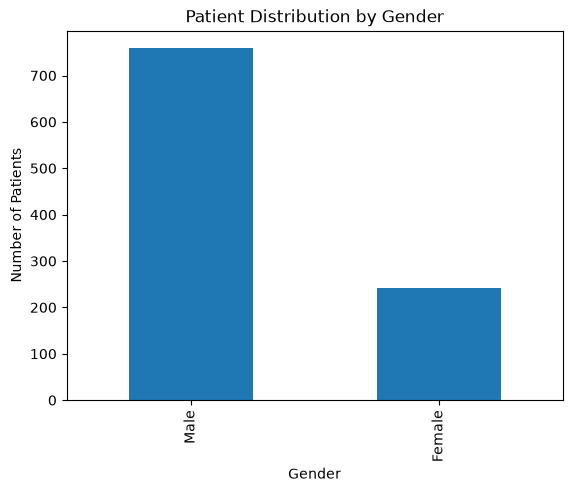

In [26]:
gender_count.plot(
    kind="bar",
    title="Patient Distribution by Gender"
)

plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.show()

In [27]:
city_count = patients["city"].value_counts()

print(city_count)

city
Bengaluru     113
Noida         113
Gurugram      110
Jaipur        107
Varanasi      104
Chandigarh    103
Pune           97
Lucknow        88
Mumbai         86
Delhi          79
Name: count, dtype: int64


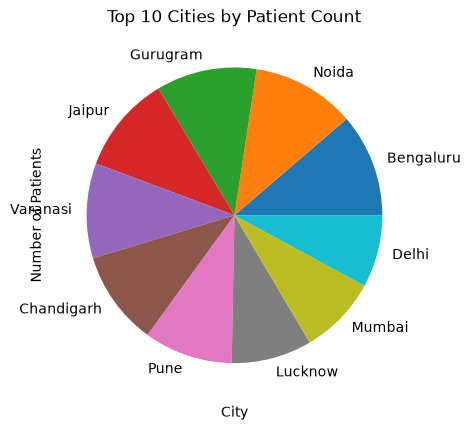

In [28]:
city_count.head(10).plot(
    kind="pie",
    title="Top 10 Cities by Patient Count"
)

plt.xlabel("City")
plt.ylabel("Number of Patients")
plt.xticks(rotation=90)
plt.show()

In [29]:
patients["date_of_birth"] = pd.to_datetime(patients["date_of_birth"])


today = pd.Timestamp.today()

patients["age"] = (
    (today - patients["date_of_birth"]).dt.days / 365.25
).astype(int)

patients[["first_name", "date_of_birth", "age"]].head(10)

bins = [0, 18, 35, 60, 100]
labels = ["0-18", "19-35", "36-60", "61+"]

patients["age_group"] = pd.cut(
    patients["age"],
    bins=bins,
    labels=labels
)

age_group_count = patients["age_group"].value_counts().sort_index()

print(age_group_count)

age_group
0-18       0
19-35    340
36-60    546
61+      114
Name: count, dtype: int64


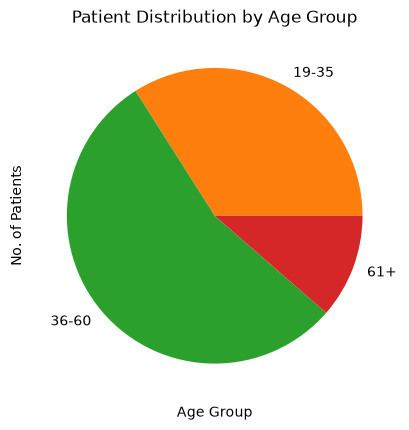

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

In [30]:
age_group_count.plot(
    kind="pie",
    title="Patient Distribution by Age Group"
)

plt.xlabel("Age Group")
plt.ylabel("No. of Patients")
plt.show()
plt.figure(figsize=(5, 4))

In [31]:


# Registration year

patients["registration_date"] = pd.to_datetime(
    patients["registration_date"]
)

patients["registration_year"] = patients["registration_date"].dt.year


# Year-wise patients


yearly_patients = (
    patients["registration_year"]
    .value_counts()
    .sort_index()
)

print(yearly_patients)

registration_year
2023    298
2024    276
2025    283
2026    143
Name: count, dtype: int64


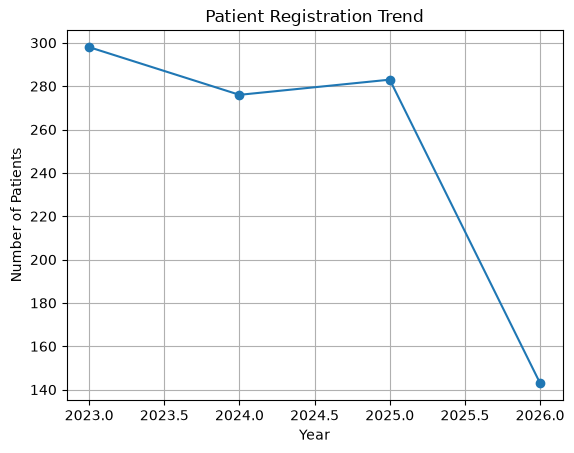

In [32]:


# Trend graph

yearly_patients.plot(
    kind="line",
    marker="o",
    title="Patient Registration Trend"
)

plt.xlabel("Year")
plt.ylabel("Number of Patients")
plt.grid()
plt.show()

In [33]:
patients["registration_month"] = patients["registration_date"].dt.month

monthly_patients = (
    patients["registration_month"]
    .value_counts()
    .sort_index()
)

print(monthly_patients)

registration_month
1      86
2      93
3      93
4      99
5     109
6      91
7      82
8      63
9      75
10     83
11     65
12     61
Name: count, dtype: int64


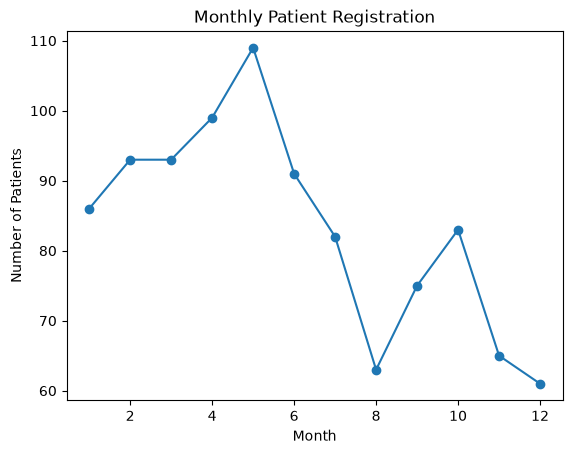

In [34]:
monthly_patients.plot(
     kind="line",
     marker="o",
    title="Monthly Patient Registration"
)

plt.xlabel("Month")
plt.ylabel("Number of Patients")
plt.show()

In [35]:
patients = pd.read_sql("SELECT * FROM patients", connection)

doctors = pd.read_sql("SELECT * FROM doctors", connection)

appointments = pd.read_sql("SELECT * FROM appointments", connection)

billing = pd.read_sql("SELECT * FROM billing", connection)

print("Patients:", patients.shape)
print("Doctors:", doctors.shape)
print("Appointments:", appointments.shape)
print("Billing:", billing.shape)

Patients: (1000, 7)
Doctors: (50, 6)
Appointments: (5000, 7)
Billing: (5000, 7)


C:\Users\dubey\AppData\Local\Temp\ipykernel_26424\4147240978.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  patients = pd.read_sql("SELECT * FROM patients", connection)
C:\Users\dubey\AppData\Local\Temp\ipykernel_26424\4147240978.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  doctors = pd.read_sql("SELECT * FROM doctors", connection)
C:\Users\dubey\AppData\Local\Temp\ipykernel_26424\4147240978.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  appointments = pd.read_sql("SELECT * FROM appointments", connection)
C

In [36]:
healthcare = appointments.merge(
    patients,
    on="patient_id",
    how="left"
)

healthcare = healthcare.merge(
    doctors,
    on="doctor_id",
    how="left"
)

healthcare = healthcare.merge(
    billing,
    on="appointment_id",
    how="left"
)

print("Shape:", healthcare.shape)
healthcare.head()

Shape: (5000, 24)


,appointment_id,patient_id_x,doctor_id,appointment_date,appointment_status,diagnosis,treatment_cost,first_name,last_name,gender,...,department,specialization,experience_years,consultation_fee,bill_id,patient_id_y,bill_date,amount,payment_method,payment_status
0,1,783,25,2025-08-18,Cancelled,Thyroid Disorder,0.0,Deepak,Verma,Male,...,Dermatology,Clinical Dermatology,10,950.0,1,33,2024-05-06,0.0,Cash,Pending
1,2,201,44,2025-03-26,Completed,Skin Allergy,953.0,Akash,Mehta,Male,...,Pediatrics,Child Medicine,10,900.0,2,581,2025-11-23,0.0,Debit Card,Pending
2,3,872,29,2023-03-15,No Show,Common Cold,0.0,Komal,Jain,Female,...,Ophthalmology,Eye Care,8,850.0,3,809,2026-04-08,4755.0,UPI,Failed
3,4,244,32,2026-06-05,Scheduled,Gastritis,0.0,Pallavi,Mehta,Female,...,Neurology,Clinical Neurology,17,1300.0,4,33,2026-05-01,1431.0,UPI,Paid
4,5,197,26,2024-10-31,Cancelled,Migraine,100.0,Pallavi,Mehta,Female,...,General Medicine,Internal Medicine,27,750.0,5,297,2023-01-09,2595.0,Insurance,Failed


In [37]:
department_analysis = (
    healthcare
    .groupby("department")
    .agg(
        total_appointments=("appointment_id", "count"),
        total_revenue=("amount", "sum"),
        avg_treatment_cost=("treatment_cost", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

department_analysis

,total_appointments,total_revenue,avg_treatment_cost
department,,,
Ophthalmology,531,1742182.0,861.357815
Pediatrics,522,1636468.0,827.854406
General Medicine,506,1518208.0,806.565217
Gynecology,506,1512268.0,803.496047
Gastroenterology,507,1505210.0,811.238659
Neurology,498,1493446.0,865.556225
Dermatology,490,1480069.0,801.767347
Orthopedics,492,1466569.0,738.065041
ENT,475,1418709.0,787.522105


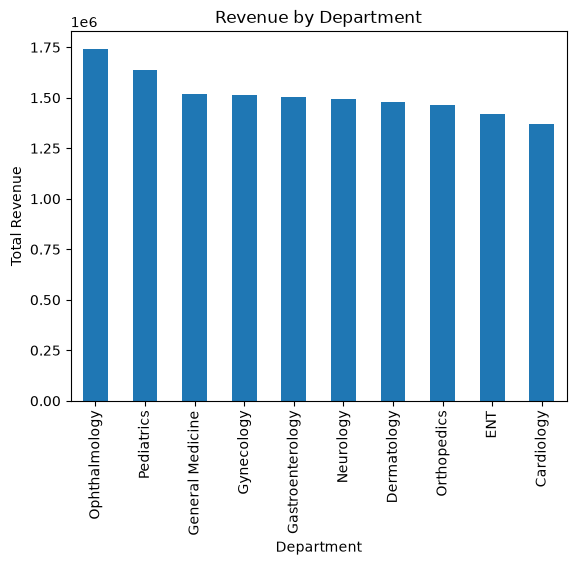

array([ 4., 16.])

In [42]:
department_analysis["total_revenue"].plot(
    kind="bar",
    title="Revenue by Department"
)

plt.xlabel("Department")
plt.ylabel("Total Revenue")
plt.xticks(rotation=90)
plt.show()

plt.figaspect(5)

In [ ]:
diagnosis_analysis = (
    healthcare
    .groupby("diagnosis")
    .agg(
        total_cases=("appointment_id", "count"),
        total_revenue=("amount", "sum"),
        avg_treatment_cost=("treatment_cost", "mean")
    )
    .round(2)
    .sort_values("total_cases", ascending=False)
)

diagnosis_analysis


,total_cases,total_revenue,avg_treatment_cost
diagnosis,,,
Arthritis,362,1125756.0,972.54
Thyroid Disorder,358,1053708.0,755.26
Hypertension,353,1080568.0,865.50
Fracture,341,1015461.0,1814.56
Migraine,341,1034070.0,592.92
Asthma,341,1095790.0,680.13
Diabetes,339,1055372.0,715.05
Common Cold,337,1077325.0,294.48
Gastritis,324,928896.0,622.94


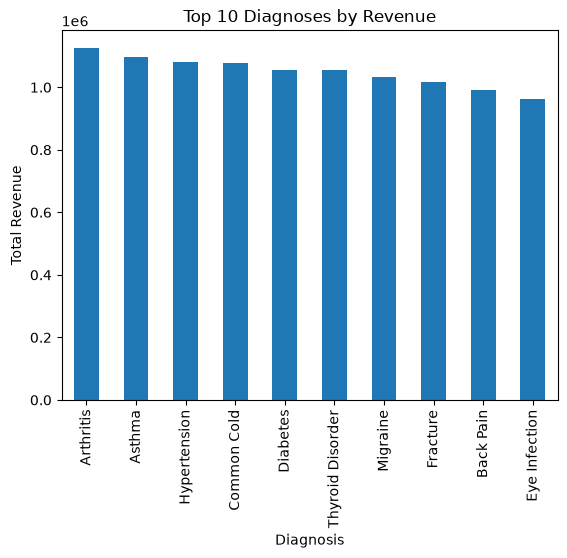

In [57]:
top_revenue_diagnosis = (
    diagnosis_analysis
    .sort_values("total_revenue", ascending=False)
    .head(10)
)

top_revenue_diagnosis["total_revenue"].plot(
    kind="bar",

    title="Top 10 Diagnoses by Revenue"
)

plt.xlabel("Diagnosis")
plt.ylabel("Total Revenue")
plt.xticks(rotation=90)
plt.show()

In [59]:
doctor_performance = (
    healthcare
    .groupby(["doctor_id", "doctor_name"])
    .agg(
        total_appointments=("appointment_id", "count"),
        total_revenue=("amount", "sum")
    )
    .round(2)
)

doctor_performance.head(3)

,,total_appointments,total_revenue
doctor_id,doctor_name,,
1,Dr. Rajesh Sharma,97,272102.0
2,Dr. Amit Verma,107,356591.0
3,Dr. Neeraj Gupta,89,266902.0


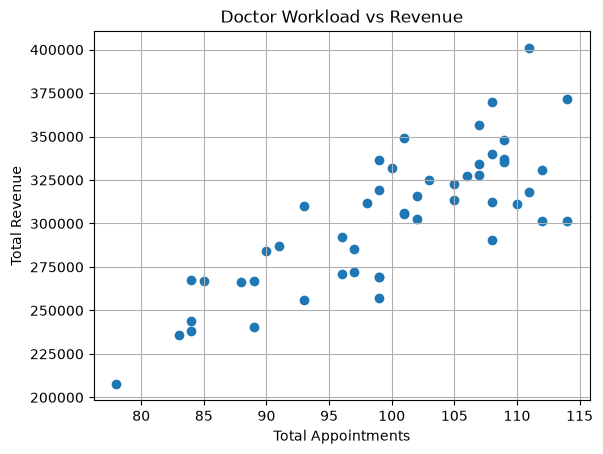

In [62]:
plt.scatter(
    doctor_performance["total_appointments"],
    doctor_performance["total_revenue"]
)

plt.title("Doctor Workload vs Revenue")
plt.xlabel("Total Appointments")
plt.ylabel("Total Revenue")
plt.grid()
plt.show()